In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF
import pandas as pd
import numpy as np
import random
import math
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rating_data_pd = pd.read_csv(
    "./cornac/data_c/ml-100k/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
rating_data = rating_data_pd.to_numpy()
rating_data.__len__()
rating_data_pd

,userID,itemID,Rating,Timestamp
0,0,0,3,881250949
1,1,1,3,891717742
2,2,2,1,878887116
3,3,3,2,880606923
4,4,4,1,886397596
...,...,...,...,...
99282,875,173,3,880175444
99283,708,247,5,879795543
99284,37,982,1,874795795
99285,58,442,2,882399156


In [3]:
df_m = pd.read_csv(
    "./cornac/data_c/ml-100K/u.item",
    sep="|",
    names=[
        "movieID",
        "Name",
        "Date",
        "Video_Date",
        "IMDB_URL",
        "unknown",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ],
    header=None,
    encoding="latin-1",
)
print(df_m.shape)
df_m = df_m[
    [
        "movieID",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ]
]

df_movies_mapped = pd.read_csv(
    "./cornac/data_c/ml-100K/i_id_mapping.csv",
    sep="\t",
    names=["movieID", "itemID"],
    header=None,
    encoding="latin-1",
)
movies = pd.merge(df_m, df_movies_mapped, how="inner", on="movieID")
movies = movies.drop(columns=["movieID"])
movies = movies.sort_values(by="itemID")
movies

(1682, 24)


,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347


In [4]:

unique_genres = [
    "Action",
    "Thriller",
    "Romance",
    "Western",
    "Children's",
    "Mystery",
    "Fantasy",
    "Film-Noir",
    "Documentary",
    "Comedy",
    "Adventure",
    "Sci-Fi",
    "Horror",
    "Crime",
    "Musical",
    "War",
    "Animation",
    "Drama",
]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()


users = pd.read_csv("./cornac/data_c/ml-100k/u_id_mapping.csv", sep="\t")
users
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
user_features_numpy = users.to_numpy()

In [5]:
def create_genre_column(r):
    all_genres = [g for g in unique_genres if r[g] == 1]
    return "|".join(all_genres)


movies["genres"] = movies.apply(create_genre_column, axis=1)
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID,genres
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Comedy
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,Thriller|Mystery|Film-Noir|Crime
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,Children's|Comedy
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3,Romance|Western|War|Drama
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4,Crime|Drama
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344,Drama
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345,Comedy
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346,Drama
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347,Drama


In [6]:

dataset = rating_data
unique_genres.__len__()

18

In [7]:
item_features_numpy[1]


array([0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [9]:


ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    val_size=0.1,
    rating_threshold=3,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,
)
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=10)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()


model_1 = UserKNN(k=20, seed=123, verbose=True, name="user knn")
model_2 = ItemKNN(k=20, seed=123, verbose=True, name="item knn")
model_3 = MF(
    k=20,
    seed=123,
    name=f"a={0} mf",
    backend="pytorch",
    verbose=True,
    optimizer="adam",
    alpha=0,max_iter=50,
    learning_rate=0.001
)
model_4 = VAECF(
    k=20,
    autoencoder_structure=[500,200],
    act_fn="relu",
    likelihood="bern",
    n_epochs=50,
    batch_size=256,
    learning_rate=0.001,
    beta=1.0,
    seed=123,alpha=0,
    verbose=True, name="a=0 vaecf"
)
model_5 = LightGCN(
    seed=123,
    verbose=True,
    emb_size=20,batch_size=256,
    num_epochs=50,alpha=0,
    
    early_stopping={"min_delta": 0.001, "patience": 20}, name="a=0 light_gcn"
)

models = [model_1, model_2, model_3, model_4]
cornac.Experiment(
    ratio_split, models=models, metrics=[prec]
    # ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, rmse, prec, hr, mrr, map]
).run()

rating_threshold = 3.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([  0,   0,   0, ..., 942, 942, 942]), array([  0,   1,   2, ..., 880, 632, 261]), array([4., 4., 4., ..., 1., 5., 4.]))
Number of users = 943
Number of items = 1348
Number of ratings = 68674
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
Global mean Imolicit= 1.0
::::::::
OrderedDict([(101, 0), (845, 1), (705, 2), (20, 3), (635, 4), (593, 5), (153, 6), (37, 7), (915, 8), (522, 9), (810, 10), (18, 11), (34, 12), (809, 13), (239, 14), (749, 15), (889, 16), (928, 17), (542, 18), (501, 19), (342, 20), (175, 21), (116, 22), (144, 23), (618, 24), (118, 25), (860, 26), (335, 27), (263, 28), (825, 29), (405, 30), (942, 31), (867, 32), (286, 33), (393, 34), (224, 35), (146, 36), (792, 37), (416, 38), (652, 39), (147, 40), (368, 41), (773, 42), (727, 43), (194, 44), (246, 45), (75, 46), (446, 47), (76, 48), (461, 49), (793, 50), (912, 51), (110, 52), (504, 53), (84, 54), (

100%|██████████| 943/943 [00:00<00:00, 63673.85it/s]



[user knn] Evaluation started!


Ranking: 100%|██████████| 943/943 [00:01<00:00, 472.92it/s]


[62, 371, 114, 579, 368, 143, 47, 538, 769, 807, 460, 473, 942, 207, 180, 469, 806, 461, 339, 212, 1, 616, 940, 861, 534, 90, 8, 439, 638, 134, 53, 120, 187, 170, 25, 408, 609, 824, 681, 367, 669, 44, 426, 477, 749, 689, 275, 755, 813, 438, 14, 566, 737, 614, 774, 860, 698, 748, 596, 527, 734, 38, 237, 107, 699, 363, 221, 462, 920, 797, 554, 95, 650, 549, 823, 466, 19, 249, 115, 508, 16, 490, 305, 576, 761, 719, 75, 399, 710, 314, 781, 690, 232, 201, 933, 634, 535, 657, 54, 12, 178, 838, 253, 891, 353, 825, 376, 866, 598, 0, 144, 81, 859, 498, 828, 854, 613, 10, 766, 908, 840, 574, 35, 448, 852, 672, 39, 847, 587, 485, 30, 914, 909, 83, 189, 524, 316, 101, 70, 836, 428, 191, 890, 551, 518, 892, 844, 162, 215, 548, 611, 79, 181, 646, 796, 486, 639, 640, 425, 285, 559, 745, 17, 102, 361, 210, 912, 356, 355, 385, 89, 222, 345, 923, 378, 507, 240, 152, 636, 394, 849, 56, 726, 662, 349, 164, 901, 630, 208, 176, 266, 28, 863, 49, 129, 348, 131, 934, 635, 656, 775, 126, 799, 392, 155, 52, 418

...

[936.15576171875, 902.764404296875, 865.853515625, 814.3612670898438, 754.0875244140625, 676.7076416015625, 588.18896484375, 491.4618835449219, 422.4066467285156, 430.4085693359375, 393.29327392578125, 313.0234069824219, 322.09320068359375, 305.1746826171875, 266.8258056640625, 228.75941467285156, 264.8546142578125, 251.80709838867188, 238.72280883789062, 218.83265686035156, 259.83984375, 250.3330078125, 237.197509765625, 214.10865783691406, 265.4954528808594, 250.52197265625, 234.686767578125, 212.5099334716797, 257.6506042480469, 245.31143188476562, 229.25535583496094, 209.2564239501953, 251.80368041992188, 244.30503845214844, 228.3881378173828, 206.36334228515625, 251.9661407470703, 234.84439086914062, 224.3454132080078, 203.88108825683594, 246.37152099609375, 232.7222900390625, 217.84524536132812, 197.6880340576172, 243.540283203125, 229.21420288085938, 215.86361694335938, 195.04580688476562, 240.48233032226562, 228.55445861816406, 211.32830810546875, 194.92044067382812, 236.402313

Ranking: 100%|██████████| 943/943 [00:00<00:00, 3551.00it/s]


[62, 371, 114, 579, 368, 143, 47, 538, 769, 807, 460, 473, 942, 207, 180, 469, 806, 461, 339, 212, 1, 616, 940, 861, 534, 90, 8, 439, 638, 134, 53, 120, 187, 170, 25, 408, 609, 824, 681, 367, 669, 44, 426, 477, 749, 689, 275, 755, 813, 438, 14, 566, 737, 614, 774, 860, 698, 748, 596, 527, 734, 38, 237, 107, 699, 363, 221, 462, 920, 797, 554, 95, 650, 549, 823, 466, 19, 249, 115, 508, 16, 490, 305, 576, 761, 719, 75, 399, 710, 314, 781, 690, 232, 201, 933, 634, 535, 657, 54, 12, 178, 838, 253, 891, 353, 825, 376, 866, 598, 0, 144, 81, 859, 498, 828, 854, 613, 10, 766, 908, 840, 574, 35, 448, 852, 672, 39, 847, 587, 485, 30, 914, 909, 83, 189, 524, 316, 101, 70, 836, 428, 191, 890, 551, 518, 892, 844, 162, 215, 548, 611, 79, 181, 646, 796, 486, 639, 640, 425, 285, 559, 745, 17, 102, 361, 210, 912, 356, 355, 385, 89, 222, 345, 923, 378, 507, 240, 152, 636, 394, 849, 56, 726, 662, 349, 164, 901, 630, 208, 176, 266, 28, 863, 49, 129, 348, 131, 934, 635, 656, 775, 126, 799, 392, 155, 52, 418

Ranking: 100%|██████████| 943/943 [00:00<00:00, 3924.18it/s]

[62, 371, 114, 579, 368, 143, 47, 538, 769, 807, 460, 473, 942, 207, 180, 469, 806, 461, 339, 212, 1, 616, 940, 861, 534, 90, 8, 439, 638, 134, 53, 120, 187, 170, 25, 408, 609, 824, 681, 367, 669, 44, 426, 477, 749, 689, 275, 755, 813, 438, 14, 566, 737, 614, 774, 860, 698, 748, 596, 527, 734, 38, 237, 107, 699, 363, 221, 462, 920, 797, 554, 95, 650, 549, 823, 466, 19, 249, 115, 508, 16, 490, 305, 576, 761, 719, 75, 399, 710, 314, 781, 690, 232, 201, 933, 634, 535, 657, 54, 12, 178, 838, 253, 891, 353, 825, 376, 866, 598, 0, 144, 81, 859, 498, 828, 854, 613, 10, 766, 908, 840, 574, 35, 448, 852, 672, 39, 847, 587, 485, 30, 914, 909, 83, 189, 524, 316, 101, 70, 836, 428, 191, 890, 551, 518, 892, 844, 162, 215, 548, 611, 79, 181, 646, 796, 486, 639, 640, 425, 285, 559, 745, 17, 102, 361, 210, 912, 356, 355, 385, 89, 222, 345, 923, 378, 507, 240, 152, 636, 394, 849, 56, 726, 662, 349, 164, 901, 630, 208, 176, 266, 28, 863, 49, 129, 348, 131, 934, 635, 656, 775, 126, 799, 392, 155, 52, 418

In [13]:
user_ids = users.to_numpy()[:, 1]
item_ids = movies.to_numpy()[:, 2]
user_ids.__len__()

943

In [17]:
users[users["Gender"]==1]

,Gender,userID
1,1,1
7,1,7
10,1,10
14,1,14
16,1,16
...,...,...
933,1,933
934,1,934
938,1,938
940,1,940


In [18]:
female_uids=[62, 371, 114, 579, 368, 143, 47, 538, 769, 807, 460, 473, 942, 207, 180, 469, 806, 461, 339, 212, 1, 616, 940, 861, 534, 90, 8, 439, 638, 134, 53, 120, 187, 170, 25, 408, 609, 824, 681, 367, 669, 44, 426, 477, 749, 689, 275, 755, 813, 438, 14, 566, 737, 614, 774, 860, 698, 748, 596, 527, 734, 38, 237, 107, 699, 363, 221, 462, 920, 797, 554, 95, 650, 549, 823, 466, 19, 249, 115, 508, 16, 490, 305, 576, 761, 719, 75, 399, 710, 314, 781, 690, 232, 201, 933, 634, 535, 657, 54, 12, 178, 838, 253, 891, 353, 825, 376, 866, 598, 0, 144, 81, 859, 498, 828, 854, 613, 10, 766, 908, 840, 574, 35, 448, 852, 672, 39, 847, 587, 485, 30, 914, 909, 83, 189, 524, 316, 101, 70, 836, 428, 191, 890, 551, 518, 892, 844, 162, 215, 548, 611, 79, 181, 646, 796, 486, 639, 640, 425, 285, 559, 745, 17, 102, 361, 210, 912, 356, 355, 385, 89, 222, 345, 923, 378, 507, 240, 152, 636, 394, 849, 56, 726, 662, 349, 164, 901, 630, 208, 176, 266, 28, 863, 49, 129, 348, 131, 934, 635, 656, 775, 126, 799, 392, 155, 52, 418, 206, 51, 684, 384, 372, 87, 919, 575, 370, 88, 556, 331, 340, 510, 667, 550, 711, 172, 500, 590, 757, 404, 332, 821, 263, 149, 786, 663, 783, 881, 442, 4, 565, 558, 642, 715, 342, 853, 756, 409, 77, 480, 32, 236, 306, 855, 758, 280, 205, 235, 936, 547, 297, 588, 532, 125, 118, 251, 37, 276, 247, 604, 885, 910, 388]
male_uids=[2, 6, 15, 23, 26, 27, 42, 45, 50, 64, 65, 66, 73, 74, 76, 78, 80, 82, 86, 91, 96, 103, 105, 109, 113, 117, 123, 127, 128, 133, 135, 136, 138, 146, 148, 150, 151, 156, 158, 161, 166, 179, 195, 199, 211, 217, 219, 227, 228, 230, 231, 234, 242, 243, 245, 248, 254, 257, 258, 259, 262, 264, 265, 270, 277, 282, 287, 292, 301, 303, 304, 307, 308, 310, 311, 312, 318, 322, 323, 324, 325, 328, 329, 330, 334, 335, 336, 338, 341, 346, 351, 354, 359, 360, 362, 365, 369, 374, 377, 381, 383, 387, 389, 397, 398, 400, 401, 402, 403, 405, 410, 419, 420, 421, 427, 432, 440, 444, 449, 453, 464, 465, 467, 468, 470, 476, 479, 481, 482, 488, 491, 492, 494, 495, 496, 512, 513, 514, 515, 516, 521, 522, 525, 528, 529, 531, 533, 536, 537, 543, 544, 546, 553, 560, 561, 562, 563, 564, 568, 571, 577, 586, 589, 592, 594, 595, 597, 602, 612, 618, 619, 620, 621, 622, 626, 627, 631, 632, 644, 645, 648, 649, 651, 655, 660, 664, 665, 668, 674, 676, 677, 680, 682, 683, 691, 692, 693, 694, 695, 696, 700, 701, 703, 716, 717, 720, 722, 725, 727, 728, 731, 739, 740, 742, 753, 759, 765, 767, 768, 770, 771, 772, 779, 782, 787, 789, 791, 793, 794, 800, 803, 808, 809, 812, 817, 819, 831, 832, 835, 837, 839, 843, 845, 846, 848, 850, 851, 856, 858, 869, 871, 875, 880, 882, 884, 893, 895, 896, 897, 900, 903, 905, 911, 916, 917, 924, 925, 927, 928, 929, 930, 937]

all_mapped_users=OrderedDict([(101, 0), (845, 1), (705, 2), (20, 3), (635, 4), (593, 5), (153, 6), (37, 7), (915, 8), (522, 9), (810, 10), (18, 11), (34, 12), (809, 13), (239, 14), (749, 15), (889, 16), (928, 17), (542, 18), (501, 19), (342, 20), (175, 21), (116, 22), (144, 23), (618, 24), (118, 25), (860, 26), (335, 27), (263, 28), (825, 29), (405, 30), (942, 31), (867, 32), (286, 33), (393, 34), (224, 35), (146, 36), (792, 37), (416, 38), (652, 39), (147, 40), (368, 41), (773, 42), (727, 43), (194, 44), (246, 45), (75, 46), (446, 47), (76, 48), (461, 49), (793, 50), (912, 51), (110, 52), (504, 53), (84, 54), (627, 55), (621, 56), (42, 57), (594, 58), (728, 59), (301, 60), (214, 61), (668, 62), (937, 63), (484, 64), (274, 65), (685, 66), (526, 67), (776, 68), (121, 69), (139, 70), (108, 71), (679, 72), (207, 73), (111, 74), (65, 75), (587, 76), (143, 77), (322, 78), (392, 79), (770, 80), (299, 81), (838, 82), (690, 83), (630, 84), (27, 85), (829, 86), (11, 87), (676, 88), (26, 89), (380, 90), (490, 91), (378, 92), (706, 93), (909, 94), (781, 95), (98, 96), (463, 97), (772, 98), (795, 99), (662, 100), (883, 101), (12, 102), (487, 103), (721, 104), (703, 105), (771, 106), (448, 107), (551, 108), (759, 109), (767, 110), (397, 111), (95, 112), (596, 113), (339, 114), (198, 115), (192, 116), (869, 117), (219, 118), (658, 119), (645, 120), (49, 121), (878, 122), (315, 123), (683, 124), (361, 125), (639, 126), (409, 127), (738, 128), (935, 129), (28, 130), (289, 131), (691, 132), (512, 133), (882, 134), (367, 135), (407, 136), (681, 137), (158, 138), (545, 139), (137, 140), (107, 141), (125, 142), (852, 143), (29, 144), (537, 145), (364, 146), (864, 147), (255, 148), (895, 149), (178, 150), (713, 151), (161, 152), (317, 153), (862, 154), (432, 155), (711, 156), (278, 157), (701, 158), (334, 159), (834, 160), (465, 161), (391, 162), (363, 163), (149, 164), (220, 165), (56, 166), (70, 167), (22, 168), (813, 169), (74, 170), (602, 171), (383, 172), (131, 173), (329, 174), (535, 175), (133, 176), (905, 177), (436, 178), (264, 179), (39, 180), (578, 181), (800, 182), (689, 183), (477, 184), (82, 185), (574, 186), (472, 187), (345, 188), (92, 189), (469, 190), (922, 191), (814, 192), (450, 193), (808, 194), (729, 195), (754, 196), (417, 197), (300, 198), (222, 199), (491, 200), (636, 201), (841, 202), (742, 203), (649, 204), (440, 205), (103, 206), (640, 207), (694, 208), (2, 209), (758, 210), (223, 211), (485, 212), (356, 213), (35, 214), (71, 215), (445, 216), (244, 217), (59, 218), (1, 219), (188, 220), (270, 221), (156, 222), (920, 223), (473, 224), (530, 225), (24, 226), (567, 227), (186, 228), (549, 229), (801, 230), (16, 231), (215, 232), (856, 233), (272, 234), (647, 235), (73, 236), (850, 237), (932, 238), (599, 239), (182, 240), (665, 241), (106, 242), (10, 243), (89, 244), (913, 245), (588, 246), (870, 247), (389, 248), (225, 249), (365, 250), (904, 251), (418, 252), (273, 253), (560, 254), (152, 255), (302, 256), (332, 257), (903, 258), (498, 259), (787, 260), (377, 261), (295, 262), (585, 263), (696, 264), (805, 265), (241, 266), (419, 267), (358, 268), (797, 269), (243, 270), (430, 271), (249, 272), (726, 273), (835, 274), (404, 275), (746, 276), (677, 277), (611, 278), (794, 279), (573, 280), (468, 281), (756, 282), (102, 283), (126, 284), (743, 285), (128, 286), (120, 287), (527, 288), (628, 289), (849, 290), (476, 291), (901, 292), (609, 293), (159, 294), (346, 295), (15, 296), (349, 297), (354, 298), (138, 299), (17, 300), (737, 301), (764, 302), (129, 303), (227, 304), (622, 305), (460, 306), (940, 307), (735, 308), (321, 309), (31, 310), (488, 311), (261, 312), (684, 313), (710, 314), (457, 315), (320, 316), (45, 317), (531, 318), (213, 319), (789, 320), (582, 321), (413, 322), (57, 323), (386, 324), (846, 325), (423, 326), (414, 327), (906, 328), (260, 329), (898, 330), (44, 331), (401, 332), (443, 333), (680, 334), (540, 335), (96, 336), (620, 337), (708, 338), (566, 339), (281, 340), (150, 341), (851, 342), (702, 343), (78, 344), (881, 345), (435, 346), (478, 347), (310, 348), (54, 349), (240, 350), (833, 351), (892, 352), (539, 353), (384, 354), (548, 355), (212, 356), (831, 357), (441, 358), (304, 359), (572, 360), (204, 361), (91, 362), (408, 363), (482, 364), (802, 365), (555, 366), (64, 367), (894, 368), (53, 369), (369, 370), (798, 371), (122, 372), (865, 373), (626, 374), (736, 375), (185, 376), (114, 377), (173, 378), (151, 379), (661, 380), (434, 381), (863, 382), (899, 383), (875, 384), (885, 385), (81, 386), (938, 387), (127, 388), (731, 389), (783, 390), (766, 391), (352, 392), (918, 393), (366, 394), (603, 395), (284, 396), (174, 397), (569, 398), (32, 399), (202, 400), (559, 401), (233, 402), (303, 403), (740, 404), (557, 405), (374, 406), (791, 407), (181, 408), (663, 409), (327, 410), (429, 411), (3, 412), (763, 413), (752, 414), (815, 415), (624, 416), (914, 417), (907, 418), (283, 419), (425, 420), (876, 421), (782, 422), (390, 423), (237, 424), (130, 425), (919, 426), (591, 427), (570, 428), (200, 429), (722, 430), (733, 431), (518, 432), (817, 433), (406, 434), (55, 435), (6, 436), (755, 437), (682, 438), (257, 439), (197, 440), (0, 441), (183, 442), (590, 443), (866, 444), (732, 445), (141, 446), (256, 447), (454, 448), (890, 449), (187, 450), (253, 451), (58, 452), (666, 453), (282, 454), (558, 455), (343, 456), (564, 457), (493, 458), (77, 459), (447, 460), (166, 461), (704, 462), (30, 463), (553, 464), (117, 465), (550, 466), (135, 467), (816, 468), (644, 469), (442, 470), (532, 471), (394, 472), (360, 473), (421, 474), (803, 475), (453, 476), (888, 477), (565, 478), (525, 479), (672, 480), (762, 481), (753, 482), (617, 483), (583, 484), (687, 485), (873, 486), (265, 487), (847, 488), (235, 489), (47, 490), (779, 491), (444, 492), (634, 493), (924, 494), (458, 495), (123, 496), (580, 497), (494, 498), (228, 499), (848, 500), (242, 501), (199, 502), (529, 503), (9, 504), (60, 505), (517, 506), (716, 507), (592, 508), (614, 509), (470, 510), (437, 511), (290, 512), (552, 513), (692, 514), (891, 515), (861, 516), (479, 517), (99, 518), (279, 519), (502, 520), (251, 521), (221, 522), (464, 523), (589, 524), (298, 525), (513, 526), (113, 527), (112, 528), (288, 529), (619, 530), (201, 531), (61, 532), (511, 533), (497, 534), (720, 535), (79, 536), (839, 537), (719, 538), (399, 539), (505, 540), (523, 541), (259, 542), (607, 543), (536, 544), (496, 545), (604, 546), (218, 547), (837, 548), (822, 549), (210, 550), (579, 551), (136, 552), (160, 553), (41, 554), (896, 555), (584, 556), (5, 557), (483, 558), (428, 559), (686, 560), (154, 561), (85, 562), (941, 563), (659, 564), (33, 565), (86, 566), (516, 567), (351, 568), (660, 569), (88, 570), (675, 571), (734, 572), (786, 573), (921, 574), (226, 575), (69, 576), (191, 577), (784, 578), (285, 579), (929, 580), (519, 581), (877, 582), (697, 583), (231, 584), (238, 585), (933, 586), (715, 587), (395, 588), (698, 589), (157, 590), (309, 591), (547, 592), (931, 593), (340, 594), (341, 595), (43, 596), (268, 597), (900, 598), (336, 599), (163, 600), (449, 601), (355, 602), (313, 603), (509, 604), (744, 605), (544, 606), (247, 607), (520, 608), (673, 609), (40, 610), (459, 611), (709, 612), (853, 613), (812, 614), (109, 615), (761, 616), (375, 617), (402, 618), (275, 619), (633, 620), (632, 621), (403, 622), (46, 623), (533, 624), (820, 625), (306, 626), (884, 627), (826, 628), (712, 629), (575, 630), (855, 631), (168, 632), (556, 633), (481, 634), (563, 635), (83, 636), (51, 637), (90, 638), (422, 639), (615, 640), (534, 641), (252, 642), (521, 643), (93, 644), (745, 645), (48, 646), (8, 647), (456, 648), (688, 649), (206, 650), (818, 651), (455, 652), (4, 653), (717, 654), (97, 655), (382, 656), (373, 657), (67, 658), (379, 659), (347, 660), (538, 661), (887, 662), (372, 663), (638, 664), (433, 665), (741, 666), (939, 667), (610, 668), (601, 669), (293, 670), (568, 671), (87, 672), (842, 673), (524, 674), (828, 675), (910, 676), (748, 677), (893, 678), (595, 679), (66, 680), (314, 681), (650, 682), (480, 683), (796, 684), (507, 685), (515, 686), (13, 687), (23, 688), (311, 689), (387, 690), (879, 691), (671, 692), (431, 693), (499, 694), (203, 695), (648, 696), (467, 697), (318, 698), (858, 699), (105, 700), (14, 701), (169, 702), (262, 703), (236, 704), (868, 705), (52, 706), (832, 707), (230, 708), (902, 709), (297, 710), (936, 711), (258, 712), (167, 713), (750, 714), (598, 715), (629, 716), (871, 717), (211, 718), (674, 719), (656, 720), (765, 721), (229, 722), (769, 723), (508, 724), (277, 725), (193, 726), (411, 727), (500, 728), (489, 729), (886, 730), (597, 731), (739, 732), (172, 733), (605, 734), (232, 735), (561, 736), (667, 737), (699, 738), (370, 739), (707, 740), (68, 741), (785, 742), (305, 743), (854, 744), (208, 745), (641, 746), (145, 747), (184, 748), (276, 749), (269, 750), (859, 751), (148, 752), (307, 753), (471, 754), (196, 755), (426, 756), (381, 757), (700, 758), (287, 759), (657, 760), (195, 761), (410, 762), (362, 763), (466, 764), (725, 765), (162, 766), (503, 767), (613, 768), (506, 769), (576, 770), (179, 771), (451, 772), (462, 773), (250, 774), (806, 775), (291, 776), (164, 777), (190, 778), (50, 779), (777, 780), (94, 781), (338, 782), (836, 783), (439, 784), (248, 785), (747, 786), (730, 787), (916, 788), (581, 789), (897, 790), (396, 791), (333, 792), (623, 793), (824, 794), (799, 795), (245, 796), (19, 797), (823, 798), (554, 799), (843, 800), (788, 801), (664, 802), (216, 803), (412, 804), (475, 805), (844, 806), (923, 807), (807, 808), (292, 809), (562, 810), (388, 811), (528, 812), (543, 813), (324, 814), (655, 815), (124, 816), (348, 817), (669, 818), (495, 819), (927, 820), (385, 821), (654, 822), (830, 823), (171, 824), (474, 825), (751, 826), (840, 827), (323, 828), (872, 829), (612, 830), (616, 831), (631, 832), (925, 833), (625, 834), (723, 835), (217, 836), (331, 837), (350, 838), (209, 839), (398, 840), (328, 841), (571, 842), (718, 843), (586, 844), (934, 845), (424, 846), (541, 847), (514, 848), (492, 849), (344, 850), (36, 851), (371, 852), (180, 853), (359, 854), (768, 855), (608, 856), (115, 857), (930, 858), (38, 859), (821, 860), (415, 861), (486, 862), (775, 863), (646, 864), (142, 865), (80, 866), (780, 867), (104, 868), (874, 869), (420, 870), (695, 871), (757, 872), (326, 873), (400, 874), (357, 875), (176, 876), (165, 877), (132, 878), (651, 879), (917, 880), (637, 881), (100, 882), (337, 883), (693, 884), (642, 885), (271, 886), (510, 887), (234, 888), (819, 889), (760, 890), (312, 891), (308, 892), (857, 893), (353, 894), (778, 895), (140, 896), (316, 897), (325, 898), (438, 899), (62, 900), (170, 901), (330, 902), (7, 903), (774, 904), (134, 905), (606, 906), (319, 907), (189, 908), (880, 909), (254, 910), (205, 911), (827, 912), (177, 913), (811, 914), (452, 915), (72, 916), (926, 917), (600, 918), (155, 919), (911, 920), (267, 921), (643, 922), (266, 923), (427, 924), (296, 925), (653, 926), (280, 927), (25, 928), (804, 929), (790, 930), (119, 931), (670, 932), (376, 933), (546, 934), (21, 935), (714, 936), (908, 937), (577, 938), (294, 939), (63, 940), (678, 941), (724, 942)])


In [14]:
# get the top_k ratings for all users:
top_k = 10
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [23]:
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df["itemID"]=range(0, len(movies))

In [43]:
male_uids_new=[]
for i in male_uids:
    for k, v in all_mapped_users.items():
        if v==i:
            male_uids_new.append(k)
female_uids_new=[]
for i in female_uids:
    for k, v in all_mapped_users.items():
        if v==i:
            female_uids_new.append(k)

for i in range(len(models)):
    df_reco = pd.DataFrame(
            {
                "userID": np.repeat(np.arange(reco_matrix[i].shape[0]), top_k),
                "itemID": reco_matrix[i].flatten(),
                "rank": np.tile(np.arange(1, top_k + 1), reco_matrix[i].shape[0]),
            }
        )


    
    all_ids = male_uids_new+female_uids_new
    df_reco = df_reco[df_reco['userID'].isin(all_ids)]
    

    df_reco = pd.merge(df_reco, movies_df, on= "itemID", how="inner")
    df_reco = df_reco.groupby("userID")[unique_genres].mean()
    df_reco = pd.merge(df_reco, users, on= "userID", how="inner")
    
    df_reco = df_reco.groupby("Gender")[unique_genres].mean()
    print("::::::::")
    print(df_reco[["Action","Romance"]])
    # print(df_reco)
    print(models[i].name)
    print("::::::::")
    



::::::::
          Action   Romance
Gender                    
0       0.055686  0.131391
1       0.054694  0.136740
user knn
::::::::
::::::::
          Action   Romance
Gender                    
0       0.067439  0.076961
1       0.053070  0.093505
item knn
::::::::
::::::::
          Action   Romance
Gender                    
0       0.078713  0.077212
1       0.076029  0.092819
a=0 mf
::::::::
::::::::
          Action   Romance
Gender                    
0       0.125570  0.088621
1       0.122757  0.090466
a=0 vaecf
::::::::


In [42]:
df_reco

,Action,Thriller,Romance,Western,Children's,Mystery,Fantasy,Film-Noir,Documentary,Comedy,Adventure,Sci-Fi,Horror,Crime,Musical,War,Animation,Drama
Gender,,,,,,,,,,,,,,,,,,
0,0.125570,0.135968,0.088621,0.0,0.011305,0.034559,0.005423,0.013419,0.0,0.147089,0.058168,0.103634,0.027941,0.045711,0.0,0.063284,0.005882,0.133425
1,0.122757,0.148100,0.090466,0.0,0.009375,0.047059,0.003493,0.013603,0.0,0.143352,0.047175,0.092365,0.034651,0.047825,0.0,0.058971,0.005882,0.134926


In [37]:
# male_uids_new=[]
# for i in male_uids:
#     for k, v in all_mapped_users.items():
#         if v==i:
#             male_uids_new.append(k)
# female_uids_new=[]
# for i in female_uids:
#     for k, v in all_mapped_users.items():
#         if v==i:
#             female_uids_new.append(k)
# for i in range(len(models)):
#     df_reco = pd.DataFrame(
#             {
#                 "userID": np.repeat(np.arange(reco_matrix[i].shape[0]), top_k),
#                 "itemID": reco_matrix[i].flatten(),
#                 "rank": np.tile(np.arange(1, top_k + 1), reco_matrix[i].shape[0]),
#             }
#         )


    
#     all_ids = male_uids_new+female_uids_new
#     df_reco = df_reco[df_reco['userID'].isin(all_ids)]

#     df_reco = pd.merge(df_reco, movies, on= "itemID", how="inner")
#     df_reco = df_reco.groupby("userID")[unique_genres].sum()
#     df_reco = pd.merge(df_reco, users, on= "userID", how="inner")

#     df_reco = df_reco.groupby("Gender")[unique_genres].sum()
#     print("::::::::")
#     print(df_reco[["Action","Romance"]])
#     # print(df_reco)
#     print(models[i].name)
#     print("::::::::")
    



::::::::
        Action  Romance
Gender                 
0          462      554
1          444      542
user knn
::::::::
::::::::
        Action  Romance
Gender                 
0          458      397
1          326      440
item knn
::::::::
::::::::
        Action  Romance
Gender                 
0          648      585
1          607      675
a=0 mf
::::::::
::::::::
        Action  Romance
Gender                 
0         1085      923
1         1048      918
a=0 vaecf
::::::::


In [26]:
np.save("reco_matrix.npy", reco_matrix)
np.save("reco_matrix_mapped_items.npy", reco_matrix_mapped_items)
np.save("reco_matrix_mapped_scores.npy", reco_matrix_mapped_scores)
np.save("reco_matrix_all.npy", reco_matrix_all)
# np.save("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [27]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMap import GenreMap
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision

top_k = 50
###intialize them
gp = GenrePrecision(users, unique_genres, top_k)
gr = GenreRecall(users, unique_genres, top_k)
gm = GenreMap(users, unique_genres, top_k)
gndcg = GenreNDCG(users, unique_genres, top_k)
gmrr = GenreMRR(users, unique_genres, top_k)

In [28]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((reco_matrix.shape[0], len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(reco_matrix.shape[0]):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_genres, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [29]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(reco_matrix.shape[0]):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], movies))
    ####Recall####
    model_grs.append(gr.compute(reco_matrix[i], movies))
    ####MAP Mean Average Precision####
    model_gms.append(gm.compute(reco_matrix[i], movies))
    ####DCG####
    model_gdcgs.append(gndcg.compute(reco_matrix[i], movies))
    ####MRR####
    model_gmrrs.append(gmrr.compute(reco_matrix[i], movies))




ValueError: All arrays must be of the same length

In [15]:
# ####IR Metrics####
# ####Rprecision####
model_grps = []
for i in range(reco_matrix.shape[0]):
    model_grps.append(grp.compute(reco_matrix_top_r[i], movies_df, movies))

          Action  Thriller   Romance   Western  Children's   Mystery  Fantasy  \
Gender                                                                          
0       0.040212  0.092668  0.080516  0.000168    0.002974  0.011491      0.0   
1       0.038650  0.092238  0.083770  0.000263    0.003771  0.011563      0.0   

        Film-Noir  Documentary    Comedy  Adventure    Sci-Fi    Horror  \
Gender                                                                    
0        0.000762     0.041552  0.152715   0.014889  0.023551  0.002714   
1        0.000935     0.040293  0.153156   0.014372  0.021000  0.003275   

           Crime   Musical       War  Animation     Drama  
Gender                                                     
0       0.041116  0.000851  0.037107   0.086524  0.382513  
1       0.038294  0.001384  0.034535   0.086466  0.382377  
[[4.02120542e-02 9.26678752e-02 8.05156837e-02 1.68388825e-04
  2.97442451e-03 1.14905074e-02 0.00000000e+00 7.62146713e-04
  4.155223

In [16]:
from operator import itemgetter
from matplotlib.ticker import MultipleLocator

unique_genres
indices = [0, 1, 2, 11, 17]
compare_genres = itemgetter(*indices)(unique_genres)

list(compare_genres)

['Action', 'Thriller', 'Romance', 'Sci-Fi', 'Drama']

In [17]:
for m in models:
    print(m.name)

user knn
item knn
a=0 mf
a=0 vaecf


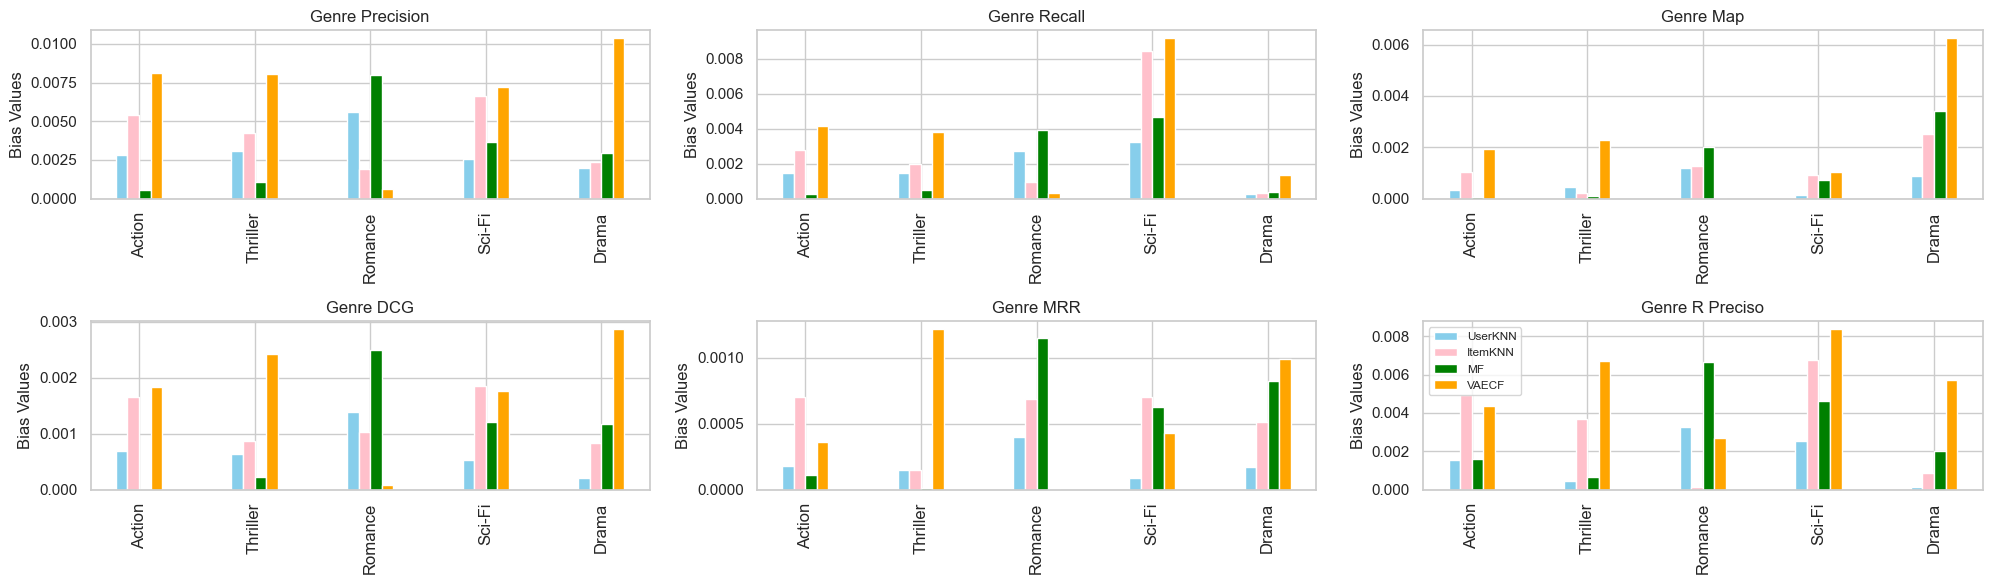

In [19]:
import matplotlib.pyplot as plt
import numpy as np
sns.set(style="whitegrid")

matrices = [
    model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
matrices_2 = [
    model_gps[1][indices],
    model_grs[1][indices],
    model_gms[1][indices],
    model_gdcgs[1][indices],
    model_gmrrs[1][indices],
    model_grps[1][indices],
]
matrices_3 = [
    model_gps[2][indices],
    model_grs[2][indices],
    model_gms[2][indices],
    model_gdcgs[2][indices],
    model_gmrrs[2][indices],
    model_grps[2][indices],
]
matrices_4 = [
    model_gps[3][indices],
    model_grs[3][indices],
    model_gms[3][indices],
    model_gdcgs[3][indices],
    model_gmrrs[3][indices],
    model_grps[3][indices],
]
# matrices_5 = [
#     model_gps[4][indices],
#     model_grs[4][indices],
#     model_gms[4][indices],
#     model_gdcgs[4][indices],
#     model_gmrrs[4][indices],
#     model_grps[4][indices],
# ]

labels = compare_genres
titles = [
    "Genre Precision",
    "Genre Recall",
    "Genre Map",
    "Genre DCG",
    "Genre MRR",
    "Genre R Preciso",
]


fig, axs = plt.subplots(2, 3, figsize=(20, 6))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.1  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(
        x - 3 * bar_width / 2, abs(matrices[i]), bar_width, color="skyblue", label="UserKNN"
    )
    axs[i].bar(
        x - 1 * bar_width / 2, abs(matrices_2[i]), bar_width, color="pink", label="ItemKNN"
    )
    axs[i].bar(
        x + 1 * bar_width / 2, abs(matrices_3[i]), bar_width, color="green", label="MF"
    )
    axs[i].bar(
        x + 3 * bar_width / 2, abs(matrices_4[i]), bar_width, color="orange", label="VAECF"
    )
    # axs[i].bar(
    #     x + 5 * bar_width / 2, abs(matrices_5[i]), bar_width, color="red", label="LightGCN"
    # )
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=12)
    axs[i].axhline(y=0, color='black', linewidth=0.5)
    axs[i].set_title(titles[i])
    # axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Bias Values")
    axs[i].tick_params(axis="x", rotation=90)
handles, labels = axs[0].get_legend_handles_labels()

plt.legend(handles, labels, loc="upper left", fontsize="8.5")

# Adjust layout
plt.tight_layout()
plt.savefig("100k_all.pdf", format="pdf")

plt.show()

In [18]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(models))]
gr_sum = [sum(abs(model_grs[i])) for i in range(len(models))]
gm_sum = [sum(abs(model_gms[i])) for i in range(len(models))]
gdcg_sum = [sum(abs(model_gdcgs[i])) for i in range(len(models))]
gmrr_sum = [sum(abs(model_gmrrs[i])) for i in range(len(models))]
grp_sum = [sum(abs(model_grps[i])) for i in range(len(models))]


In [19]:
gp_sum

[0.028300246022634045,
 0.06752932095149575,
 0.04735875567218856,
 0.05284490004191491,
 0.03687868350554912]

In [20]:
gr_sum

[0.034043719068074615,
 0.0748939934632972,
 0.06987493575527315,
 0.05216615587493527,
 0.03724239502499824]

In [21]:
gm_sum

[0.004021374128561666,
 0.017608614236904463,
 0.011822017946587398,
 0.013762529646796352,
 0.008962711529850266]

In [22]:
gdcg_sum

[0.006307287442772572,
 0.01814120828837455,
 0.015313039322092397,
 0.014423979533454132,
 0.010116629145957453]

In [23]:
gmrr_sum

[0.0017327635402781386,
 0.007073451173631905,
 0.008049846747490432,
 0.005663659699868925,
 0.004191425829967416]

In [24]:
grp_sum

[0.01783365942987266,
 0.056776788048756535,
 0.052220792862854824,
 0.04878815928773944,
 0.03589207028059625]